# SO(3) Right-Invariant InEKF Covariance Tuning

A small CUDA/Torch tutorial:

- generate synthetic SO(3) attitude data
- run a differentiable right-invariant attitude InEKF
- learn diagonal Q/R with an SO(3) trajectory loss
- compare Adam with SGD+momentum

Everything uses float64. The Kalman gain is solved with `torch.linalg.solve`, and covariance updates use Joseph form.


In [1]:
import math
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', device, '|', torch.cuda.get_device_name(0) if device=='cuda' else '')

device = cuda | NVIDIA GeForce RTX 5090 Laptop GPU


### SO(3) Operators

Batch-friendly `hat`, `vee`, `so3_exp`, and `so3_log`. `so3_exp` adds a tiny epsilon in the norm to avoid division by zero near zero rotation.


In [2]:
def hat(w):
    # w: (..., 3) -> (..., 3, 3)
    z = torch.zeros_like(w[..., 0])
    r0 = torch.stack([z, -w[..., 2], w[..., 1]], dim=-1)
    r1 = torch.stack([w[..., 2], z, -w[..., 0]], dim=-1)
    r2 = torch.stack([-w[..., 1], w[..., 0], z], dim=-1)
    return torch.stack([r0, r1, r2], dim=-2)


def vee(W):
    return torch.stack([W[..., 2, 1], W[..., 0, 2], W[..., 1, 0]], dim=-1)


def so3_exp(phi):
    th = torch.sqrt((phi * phi).sum(-1, keepdim=True) + 1e-24)
    K = hat(phi)
    a = (torch.sin(th) / th)[..., None]
    b = ((1 - torch.cos(th)) / (th * th))[..., None]
    I = torch.eye(3, dtype=phi.dtype, device=phi.device)
    return I + a * K + b * (K @ K)


def so3_log(R):
    tr = R[..., 0, 0] + R[..., 1, 1] + R[..., 2, 2]
    cos = ((tr - 1) * 0.5).clamp(-1.0, 1.0)
    w = vee(R - R.transpose(-1, -2))
    sin = torch.linalg.norm(w, dim=-1) * 0.5
    th = torch.atan2(sin, cos)
    scale = th / (2 * sin + 1e-24)
    return scale[..., None] * w


_phi = torch.tensor([0.1, -0.2, 0.05])
print('exp/log round-trip error:', (so3_log(so3_exp(_phi)) - _phi).abs().max().item())


exp/log round-trip error: 0.0


### Synthetic Data

The angular velocity is a smooth sinusoidal signal. The gyroscope is the true angular velocity plus small noise. The attitude measurement is the ground-truth attitude composed with larger SO(3) noise.


In [3]:
def make_data(T=200, dt=0.02, gyro_sigma=0.01, meas_sigma=0.05, seed=0):
    gen = torch.Generator().manual_seed(seed)
    t = torch.arange(T) * dt
    omega_true = torch.stack([
        0.6 * torch.sin(0.7 * t),
        0.5 * torch.cos(0.5 * t),
        0.4 * torch.sin(0.3 * t + 0.5),
    ], dim=-1)

    Rgt = torch.zeros(T, 3, 3)
    Rgt[0] = torch.eye(3)
    for k in range(T - 1):
        Rgt[k + 1] = Rgt[k] @ so3_exp(omega_true[k] * dt)

    gyro = omega_true + gyro_sigma * torch.randn(T, 3, generator=gen)
    Rmeas = Rgt @ so3_exp(meas_sigma * torch.randn(T, 3, generator=gen))
    return omega_true, Rgt, gyro, Rmeas


T, dt = 200, 0.02
gyro_sigma, meas_sigma = 0.01, 0.05
omega_true, Rgt, gyro, Rmeas = make_data(T, dt, gyro_sigma, meas_sigma, seed=0)
Rgt, gyro, Rmeas = Rgt.to(device), gyro.to(device), Rmeas.to(device)
data = (gyro, Rmeas, Rgt)

print(f"reference diagQ scale ~ (gyro_sigma * dt)^2 = {(gyro_sigma * dt) ** 2:.3e}")
print(f"reference diagR scale ~ meas_sigma^2       = {meas_sigma ** 2:.3e}")


reference diagQ scale ~ (gyro_sigma * dt)^2 = 4.000e-08
reference diagR scale ~ meas_sigma^2       = 2.500e-03


### Differentiable InEKF

`raw_q` and `raw_r` are learnable diagonal covariance parameters. `softplus` keeps Q and R positive. The rollout is fully differentiable, including propagation, innovation, Kalman gain, and Joseph covariance update.


In [4]:
import torch.nn as nn
import torch.nn.functional as F


class SO3InEKF(nn.Module):
    def __init__(self, raw_q_init, raw_r_init, eps=1e-6):
        super().__init__()
        self.raw_q = nn.Parameter(torch.tensor(raw_q_init))
        self.raw_r = nn.Parameter(torch.tensor(raw_r_init))
        self.eps = eps

    def covs(self):
        q = F.softplus(self.raw_q) + self.eps
        r = F.softplus(self.raw_r) + self.eps
        return torch.diag(q), torch.diag(r)

    def forward(self, gyro, Rmeas, dt):
        Q, Rc = self.covs()
        I = torch.eye(3, dtype=gyro.dtype, device=gyro.device)
        Rhat = Rmeas[0].clone()
        P = 0.01 * I
        out = []
        for k in range(gyro.shape[0]):
            Rp = Rhat @ so3_exp(gyro[k] * dt)
            Fk = so3_exp(-gyro[k] * dt)
            Pp = Fk @ P @ Fk.T + Q

            res = so3_log(Rp.T @ Rmeas[k])
            S = Pp + Rc
            K = torch.linalg.solve(S.T, Pp.T).T
            Rhat = Rp @ so3_exp(K @ res)
            IK = I - K
            P = IK @ Pp @ IK.T + K @ Rc @ K.T
            out.append(Rhat)
        return torch.stack(out)


def loss_fn(Rhat, Rgt):
    e = so3_log(Rgt.transpose(-1, -2) @ Rhat)
    return (e * e).sum(-1).mean()


### Bad Initialization

Start with Q too large and R too small. The filter over-trusts noisy measurements. Training should reduce Q, increase R, and move the gain toward a smoother compromise.


In [5]:
raw_q_init = [1.0, 1.0, 1.0]
raw_r_init = [-3.0, -3.0, -3.0]

m0 = SO3InEKF(raw_q_init, raw_r_init).to(device)
Q0, R0 = m0.covs()
print('init diagQ =', Q0.diag().detach().cpu().numpy())
print('init diagR =', R0.diag().detach().cpu().numpy())
with torch.no_grad():
    print('init loss  =', loss_fn(m0(gyro, Rmeas, dt), Rgt).item())


init diagQ = [1.31326269 1.31326269 1.31326269]
init diagR = [0.04858835 0.04858835 0.04858835]


init loss  = 0.007741521475046356


### Train: Adam vs SGD+Momentum


In [6]:
def train(opt_kind, lr, steps, log_every=100):
    torch.manual_seed(0)
    model = SO3InEKF(raw_q_init, raw_r_init).to(device)
    if opt_kind == 'adam':
        opt = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    losses = []
    for s in range(steps):
        opt.zero_grad()
        loss = loss_fn(model(gyro, Rmeas, dt), Rgt)
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if s % log_every == 0 or s == steps-1:
            Q, Rc = model.covs()
            print(f"[{opt_kind:4s}] step {s:4d}  loss {loss.item():.4e}  "
                  f"diagQ {Q.diag().detach().cpu().numpy().round(6)}  "
                  f"diagR {Rc.diag().detach().cpu().numpy().round(6)}")
    return model, losses

In [7]:
model_adam, loss_adam = train('adam', 3e-2, 400)

[adam] step    0  loss 7.7415e-03  diagQ [1.291422 1.291423 1.291422]  diagR [0.050032 0.050032 0.050032]


[adam] step  100  loss 1.4779e-03  diagQ [0.07854  0.079352 0.084991]  diagR [0.782643 0.783786 0.742933]


[adam] step  200  loss 6.0339e-04  diagQ [0.016243 0.019647 0.020749]  diagR [1.451089 1.388497 1.309767]


[adam] step  300  loss 4.9011e-04  diagQ [0.007765 0.011123 0.010857]  diagR [1.725403 1.642479 1.54169 ]


[adam] step  399  loss 4.6485e-04  diagQ [0.004885 0.008471 0.008208]  diagR [1.849092 1.778737 1.607262]


In [8]:
model_sgd, loss_sgd = train('sgd', 3.0, 400)  # SGD needs a much larger lr here.


[sgd ] step    0  loss 7.7415e-03  diagQ [1.313056 1.313092 1.313058]  diagR [0.048612 0.048608 0.048612]


[sgd ] step  100  loss 7.3103e-03  diagQ [1.077808 1.125688 1.0813  ]  diagR [0.084091 0.075232 0.083411]


[sgd ] step  200  loss 5.6971e-03  diagQ [0.635759 0.792041 0.652261]  diagR [0.233893 0.162052 0.224863]


[sgd ] step  300  loss 2.9397e-03  diagQ [0.233939 0.363296 0.256963]  diagR [0.655325 0.454972 0.610783]


[sgd ] step  399  loss 1.6137e-03  diagQ [0.098729 0.156564 0.121628]  diagR [1.05087  0.836925 0.951236]


### Plots


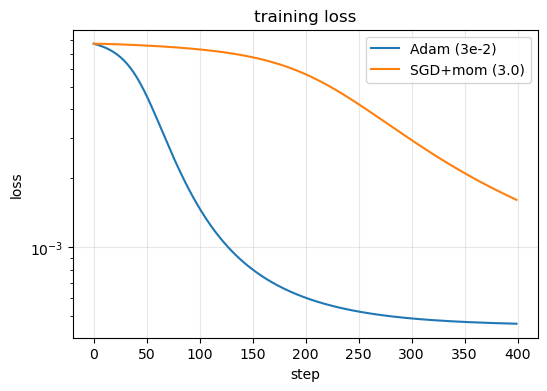

In [9]:
plt.figure(figsize=(6,4))
plt.semilogy(loss_adam, label='Adam (3e-2)')
plt.semilogy(loss_sgd,  label='SGD+mom (3.0)')
plt.xlabel('step'); plt.ylabel('loss'); plt.title('training loss')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

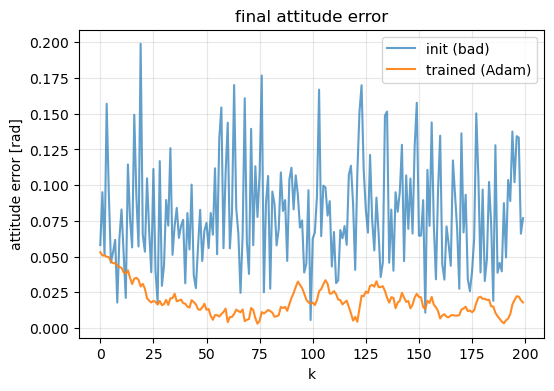

In [10]:
with torch.no_grad():
    err_init = so3_log(Rgt.transpose(-1,-2) @ m0(gyro, Rmeas, dt)).norm(dim=-1)
    err_adam = so3_log(Rgt.transpose(-1,-2) @ model_adam(gyro, Rmeas, dt)).norm(dim=-1)

plt.figure(figsize=(6,4))
plt.plot(err_init.cpu(), label='init (bad)', alpha=0.7)
plt.plot(err_adam.cpu(), label='trained (Adam)', alpha=0.9)
plt.xlabel('k'); plt.ylabel('attitude error [rad]')
plt.title('final attitude error'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

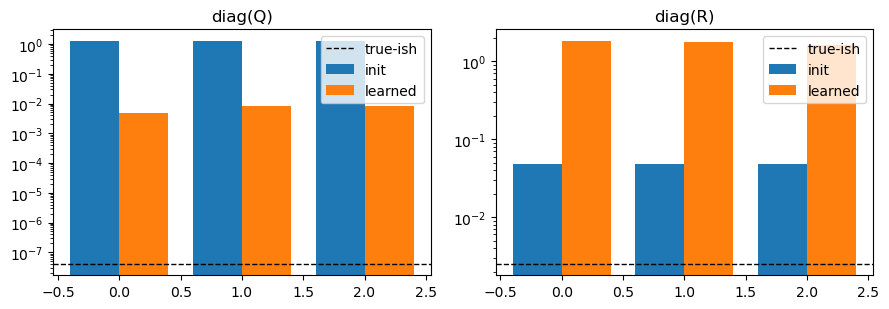

learned sqrt(diagQ) = [0.06988924 0.09204062 0.09059928]  vs gyro*dt = 0.0002
learned sqrt(diagR) = [1.35981319 1.33369314 1.26777833]  vs meas_sigma = 0.05


In [11]:
import numpy as np
Qa, Ra = model_adam.covs()
qa, ra = Qa.diag().detach().cpu().numpy(), Ra.diag().detach().cpu().numpy()
x = np.arange(3)
fig, ax = plt.subplots(1, 2, figsize=(9,3.2))
ax[0].bar(x-0.2, Q0.diag().detach().cpu().numpy(), 0.4, label='init')
ax[0].bar(x+0.2, qa, 0.4, label='learned')
ax[0].axhline((gyro_sigma*dt)**2, ls='--', c='k', lw=1, label='true-ish')
ax[0].set_title('diag(Q)'); ax[0].set_yscale('log'); ax[0].legend()
ax[1].bar(x-0.2, R0.diag().detach().cpu().numpy(), 0.4, label='init')
ax[1].bar(x+0.2, ra, 0.4, label='learned')
ax[1].axhline(meas_sigma**2, ls='--', c='k', lw=1, label='true-ish')
ax[1].set_title('diag(R)'); ax[1].set_yscale('log'); ax[1].legend()
plt.tight_layout(); plt.show()

print("learned sqrt(diagQ) =", np.sqrt(qa), " vs gyro*dt =", gyro_sigma*dt)
print("learned sqrt(diagR) =", np.sqrt(ra), " vs meas_sigma =", meas_sigma)

### Takeaways

- Adam is easier to tune here: `3e-2` gives stable progress because the adaptive denominator rescales small gradients.
- SGD+momentum is more learning-rate sensitive: this toy needs `3.0`, roughly 100x Adam's step size.
- Autograd moves Q down and R up from the intentionally bad initialization. The learned scales minimize trajectory error; they do not have to equal the data-generation noise exactly.
- The same idea scales to the full InEKF: Lie operations, covariance propagation, Kalman gain, and the trajectory loss all live in one differentiable Torch graph.
